In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [6]:
df = pd.read_csv("/content/BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [8]:
X = df.drop("medv",axis=1)
y = df["medv"]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scalar=StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test =scalar.transform(X_test)


In [ ]:
model = Sequential()
model.add(Dense(64,activation="relu",))
model.add(Dense(32,activation="relu"))
model.add(Dense(1,activation="linear"))

model.compile(optimizer="adam",loss="mse",metrics=["mae"])

history = model.fit(X_train,y_train,epochs=100,batch_size=16)

In [35]:
loss , mae = model.evaluate(X_test,y_test)
print("MAE :- ",mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.7736 - mae: 2.1310
MAE :-  2.1310195922851562


Text(0, 0.5, 'loss')

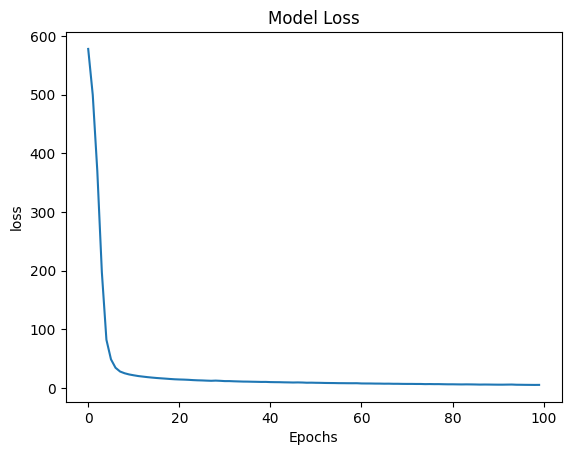

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("loss")